# Limpeza Conflitos para ID no Dataset


## Objetivo

• Verificar no dataset os conflitos dos ids, fazer a separação  de um DataFrame de registros removidos e registros sem conflito



## Bibliotecas

In [1]:
# Importa as Bibliotecas

# Manipulação de dados
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
"""
# Importa as Bibliotecas 

# Manipulação de dados
import pandas as pd

# Divisão de treino e teste
from sklearn.model_selection import train_test_split

# Transformação de texto em números (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Pipeline para unir TF-IDF + modelo
from sklearn.pipeline import Pipeline

# Avaliação dos modelos
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Serialização 
from joblib import dump, load
"""

'\n# Importa as Bibliotecas \n\n# Manipulação de dados\nimport pandas as pd\n\n# Divisão de treino e teste\nfrom sklearn.model_selection import train_test_split\n\n# Transformação de texto em números (TF-IDF)\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Modelos de classificação\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.svm import LinearSVC\n\n# Pipeline para unir TF-IDF + modelo\nfrom sklearn.pipeline import Pipeline\n\n# Avaliação dos modelos\nfrom sklearn.metrics import (\n    accuracy_score,\n    classification_report,\n    confusion_matrix\n)\n\n# Serialização \nfrom joblib import dump, load\n'

## Carregamento dos Dados

In [3]:
# Carregando dados 
df = pd.read_csv('../dados/base_artigos_en.csv')
df.head(1)

,categoria,collection_id,comments_count,created_at,crossposted_at,description,edited_at,flare_tag,id,language,...,published_timestamp,readable_publish_date,reading_time_minutes,subcategoria,subforem_id,tag_list,tags,texto,title,type_of
0,Frontend,NaN,0,2026-07-18T19:29:08Z,NaN,Choosing a state management library feels a bi...,2026-07-18T19:31:43Z,NaN,4175536,en,...,2026-07-18T19:29:08Z,Jul 18,3,frontend,1.0,"['architecture', 'frontend', 'react', 'typescr...","architecture, frontend, react, typescript",Choosing a state management library feels a bi...,Stop Over Engineering Your Frontend State: A D...,article


## Funções e Variáveis Auxiliares

## Conhecendo o Dataset

#### Dicionário de dados

In [4]:
# incluir tabela com coluna e descrição


### Conhecendo Dados e Estruturas

In [5]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   categoria                 1851 non-null   str    
 1   collection_id             150 non-null    float64
 2   comments_count            1851 non-null   int64  
 3   created_at                1851 non-null   str    
 4   crossposted_at            15 non-null     str    
 5   description               1851 non-null   str    
 6   edited_at                 322 non-null    str    
 7   flare_tag                 85 non-null     str    
 8   id                        1851 non-null   int64  
 9   language                  1851 non-null   str    
 10  last_comment_at           1851 non-null   str    
 11  positive_reactions_count  1851 non-null   int64  
 12  public_reactions_count    1851 non-null   int64  
 13  published_at              1851 non-null   str    
 14  published_timestamp

## Análise Exploratória

### Categorias

In [6]:
df['categoria'].value_counts()

categoria
Security       346
Frontend       341
Backend        338
Database       324
Cloud          287
DataScience    215
Name: count, dtype: int64

<Axes: title={'center': 'Quantidade de Artigos por Categoria'}, xlabel='categoria'>

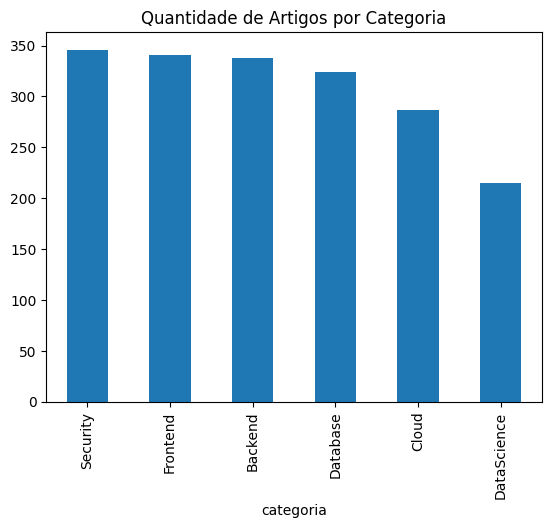

In [7]:
# Checagem Balanceamento
df['categoria'].value_counts().plot(kind='bar', title='Quantidade de Artigos por Categoria')

### Valores Duplicados

In [8]:
# Verificando registros duplicados por linha
df.duplicated().sum()

np.int64(0)

In [9]:
# Quantidade de registros duplicados por id 
df['id'].duplicated().sum()

np.int64(253)

In [10]:
# Verificando Ids duplicados
df[df['id'].duplicated(keep=False)].sort_values('id')[['categoria', 'subcategoria', 'id', 'texto', 'tags']].head(5)

,categoria,subcategoria,id,texto,tags
718,Cloud,cloud,3450296,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
857,Cloud,azure,3450296,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
816,Cloud,aws,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
377,Backend,backend,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
800,Cloud,aws,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."


Há registros duplicados por id. Isso ocorre porque a base é obtida através da subcategoria, que no caso pode ser diferente. Os registros duplicados serão descartados.

Há registros duplicado por id, porém de categorias diferentes. Verificar quantos casos desse tipo.



In [11]:
# Quantidade de conflitos (id igual e categoria diferente)
conflitos = df[df['id'].duplicated(keep=False)].groupby('id')['categoria'].nunique()
(conflitos > 1).sum()

np.int64(71)

In [12]:
# Verificando registros com conflitos
ids_conflito = conflitos[conflitos > 1].index

df[df['id'].isin(ids_conflito)].sort_values('id')[['categoria', 'subcategoria', 'id', 'texto', 'tags']].head(10)

,categoria,subcategoria,id,texto,tags
377,Backend,backend,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
816,Cloud,aws,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1704,DataScience,machinelearning,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
800,Cloud,aws,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
1297,Security,security,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
511,Backend,api,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
342,Backend,backend,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
967,Database,database,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
516,Backend,api,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"
286,Frontend,nextjs,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"


São 71 casos com textos iguais e categorias diferentes 

## Inicio da Parte a ser considerada para conflitos id

In [13]:
# Filtra os conflitos, pega a coluna 'subcategoria', remove repetições e converte para lista
subcategorias_conflito = df[df['id'].isin(ids_conflito)]['subcategoria'].unique().tolist()

print(subcategorias_conflito)

['javascript', 'react', 'typescript', 'nextjs', 'backend', 'springboot', 'java', 'api', 'php', 'cloud', 'aws', 'azure', 'docker', 'database', 'postgres', 'nosql', 'sql', 'mongodb', 'security', 'cybersecurity', 'infosec', 'datascience', 'machinelearning', 'python']


In [14]:
df['categoria'].value_counts()

categoria
Security       346
Frontend       341
Backend        338
Database       324
Cloud          287
DataScience    215
Name: count, dtype: int64

In [15]:
print(df['subcategoria'].value_counts())

subcategoria
security           60
infosec            60
cryptography       60
javascript         59
java               59
api                59
aws                59
azure              59
database           59
ethicalhacking     59
typescript         58
nextjs             58
cloud              58
kubernetes         58
nosql              58
cybersecurity      58
datascience        58
python             58
react              56
backend            56
csharp             56
postgres           56
frontend           55
css                55
springboot         54
php                54
mongodb            54
docker             53
sql                52
machinelearning    52
mfa                49
pandas             47
crud               45
Name: count, dtype: int64


In [16]:
df_conflitos = df[df['id'].isin(ids_conflito)].sort_values('id')[['categoria', 'subcategoria', 'id', 'texto', 'tags']]

In [17]:
len(df_conflitos)

153

In [18]:
# Conta quantas vezes cada ID em conflito aparece na base
df_conflitos['id'].value_counts().describe()

count    71.000000
mean      2.154930
std       0.401707
min       2.000000
25%       2.000000
50%       2.000000
75%       2.000000
max       4.000000
Name: count, dtype: float64

Verificação da quantidade de ids. O mesmo id aparece na base 4 vezes

In [19]:
# Dicionário de regras (Chave = subcategoria)
# nota: Valor da nota conforme critério adotado na amostra - 2 = categoria correta
# qtd_sub: Quantidade de registros por subcategorias
# qtd_cat: Quantidade de registros por subcategorias

metrica_conflito = {
    'javascript': {'nota': 83.33, 'qtd_sub': 56, 'qtd_cat': 341},
    'react': {'nota': 100.0, 'qtd_sub': 27, 'qtd_cat': 341},
    'typescript': {'nota': 0.0, 'qtd_sub': 40, 'qtd_cat': 341},
    'nextjs': {'nota': 83.33, 'qtd_sub': 50, 'qtd_cat': 341},
    'backend': {'nota': 100.0, 'qtd_sub': 49, 'qtd_cat': 338},
    'springboot': {'nota': 100.0, 'qtd_sub': 45, 'qtd_cat': 338},
    'java': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 338},
    'api': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 338},
    'php': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 338},
    'cloud': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 287},
    'aws': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 287},
    'azure': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 287},
    'docker': {'nota': 100.0, 'qtd_sub': 53, 'qtd_cat': 287},
    'database': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 324},
    'postgres': {'nota': 100.0, 'qtd_sub': 56, 'qtd_cat': 324},
    'nosql': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 324},
    'sql': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 324},
    'mongodb': {'nota': 60.0, 'qtd_sub': 54, 'qtd_cat': 324},
    'security': {'nota': 100.0, 'qtd_sub': 60, 'qtd_cat': 346},
    'cybersecurity': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 346},
    'infosec': {'nota': 100.0, 'qtd_sub': 60, 'qtd_cat': 346},
    'datascience': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 215},
    'machinelearning': {'nota': 20.0, 'qtd_sub': 52, 'qtd_cat': 215},
    'python': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 215}
}

In [20]:
registros_mantidos = {}   # Guarda o vencedor de cada um dos 71 IDs
registros_removidos = []  # Guarda os perdedores dos conflitos

colunas_originais = ['categoria', 'subcategoria', 'id', 'texto', 'tags']

# 2. Percorre apenas as linhas dos 71 conflitos
for linha in df_conflitos.to_dict('records'):
    
    # BUSCA DIRETA NO DICIONÁRIO
    # Lê a subcategoria atual
    sub = linha['subcategoria']
    # Busca a nota e contagens no dicionário (usa nota 0 e qtd 99999 para penalizar desconhecidos)
    regras = metrica_conflito.get(sub, {'nota': 0, 'qtd_sub': 99999, 'qtd_cat': 99999})

    # Adiciona as métricas na linha atual
    linha['nota'] = regras['nota']
    linha['qtd_sub'] = regras['qtd_sub']
    linha['qtd_cat'] = regras['qtd_cat']

    id_atual = linha['id']

    # Se esse 'id' de conflito ainda não foi visto no laço:
    if id_atual not in registros_mantidos:
        registros_mantidos[id_atual] = linha
        
    # Se esse 'id' já está no dicionário -> Aplica a Regra de Desempate!
    else:
        registro_atual = registros_mantidos[id_atual]
        registro_novo = linha

        # --- ESTRUTURA DE COMPARAÇÃO ---
        # 1º Critério: Maior nota vence
        if registro_novo['nota'] > registro_atual['nota']:
            vencedor = registro_novo
            perdedor = registro_atual
        elif registro_novo['nota'] < registro_atual['nota']:
            vencedor = registro_atual
            perdedor = registro_novo
        else:
            # 2º Critério: Menor qtd de subcategoria vence
            if registro_novo['qtd_sub'] < registro_atual['qtd_sub']:
                vencedor = registro_novo
                perdedor = registro_atual
            elif registro_novo['qtd_sub'] > registro_atual['qtd_sub']:
                vencedor = registro_atual
                perdedor = registro_novo
            else:
                # 3º Critério: Menor qtd de categoria vence
                if registro_novo['qtd_cat'] < registro_atual['qtd_cat']:
                    vencedor = registro_novo
                    perdedor = registro_atual
                else:
                    vencedor = registro_atual
                    perdedor = registro_novo

        # Atualiza o vencedor e guarda o perdedor
        registros_mantidos[id_atual] = vencedor
        registros_removidos.append(perdedor)


In [21]:
# DataFrames finais
df_removidos = pd.DataFrame(registros_removidos)[colunas_originais]
df_limpo = pd.DataFrame(list(registros_mantidos.values()))[colunas_originais]

In [22]:
df_removidos.head()

,categoria,subcategoria,id,texto,tags
0,Cloud,aws,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1,DataScience,machinelearning,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
2,Security,security,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
3,Database,database,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
4,Frontend,nextjs,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"


In [23]:
len(df_removidos)

82

In [24]:
df_removidos['id'].value_counts().describe()

count    71.000000
mean      1.154930
std       0.401707
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: count, dtype: float64

In [25]:
df_limpo.head()

,categoria,subcategoria,id,texto,tags
0,Backend,backend,3509884,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1,Cloud,aws,3790359,"---\ndescription: ""SDAR claims it beats GRPO a...","aws, machinelearning, mlops, reinforcementlear..."
2,Backend,api,3965827,"---\ntitle: ""Create and secure webhooks with t...","api, webhooks, security, devtools"
3,Backend,backend,4056069,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
4,Backend,api,4107706,\n\n## TL;DR\n\n- Best Sanity CMS use cases in...,"api, nextjs, saas, webdev"


In [26]:
len(df_limpo)

71

In [27]:
df_limpo['id'].value_counts().describe()

count    71.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: count, dtype: float64